In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('GaltonFamilies.csv')

# Inspect it
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nBasic Stats:\n", df.describe())

   rownames family  father  mother  midparentHeight  children  childNum  \
0         1    001    78.5    67.0            75.43         4         1   
1         2    001    78.5    67.0            75.43         4         2   
2         3    001    78.5    67.0            75.43         4         3   
3         4    001    78.5    67.0            75.43         4         4   
4         5    002    75.5    66.5            73.66         4         1   

   gender  childHeight  
0    male         73.2  
1  female         69.2  
2  female         69.0  
3  female         69.0  
4    male         73.5  

Columns: ['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children', 'childNum', 'gender', 'childHeight']

Shape: (934, 9)

Basic Stats:
          rownames      father      mother  midparentHeight    children  \
count  934.000000  934.000000  934.000000       934.000000  934.000000   
mean   467.500000   69.197109   64.089293        69.206773    6.171306   
std    269.766875    2.4

Total data points: 1868
Global mean (the 'naive split' line): 65.42


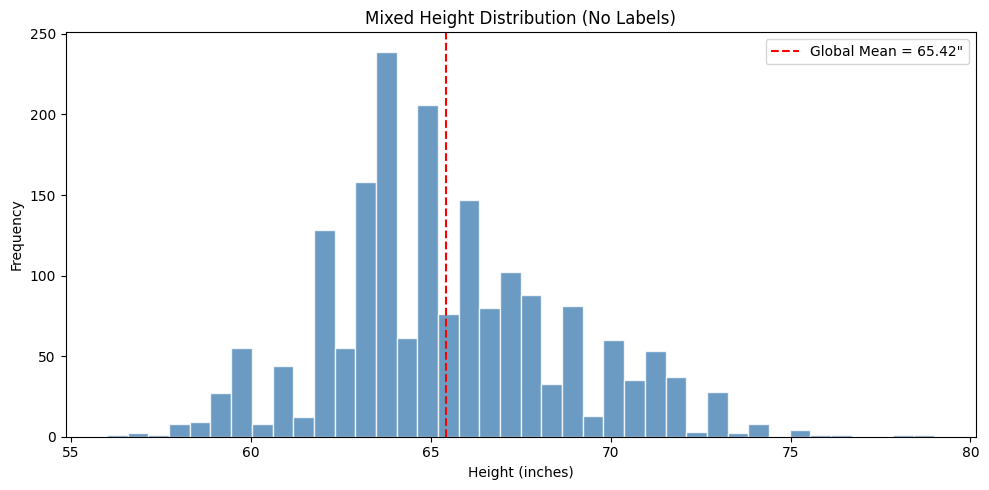

In [29]:
mother_heights = df['mother'].dropna().values
child_heights = df['childHeight'].dropna().values

# unlabeled dataset the mixture
all_heights = np.concatenate([mother_heights, child_heights])

print(f"Total data points: {len(all_heights)}")
print(f"Global mean (the 'naive split' line): {all_heights.mean():.2f}")

# Visualize the mixture
plt.figure(figsize=(10, 5))
plt.hist(all_heights, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(all_heights.mean(), color='red', linestyle='--', label=f'Global Mean = {all_heights.mean():.2f}"')
plt.title('Mixed Height Distribution (No Labels)')
plt.xlabel('Height (inches)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import norm

def gaussian_pdf(x, mu, sigma):
    "Probability density of x under a Gaussian with given mu and sigma."
    return norm.pdf(x, mu, sigma)


def initialize_params(data, seed=42):
    "Randomly initialize the two Gaussian components."
    np.random.seed(seed)

    idx = np.random.choice(len(data), 2, replace=False)
    mu1, mu2 = data[idx[0]], data[idx[1]]
    sigma1 = sigma2 = np.std(data)
    pi1 = pi2 = 0.5
    return mu1, mu2, sigma1, sigma2, pi1, pi2


def e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    #compute responsibilities
    """
    r1[i] = probability that point i belongs to component 1 (Children)
    r2[i] = probability that point i belongs to component 2 (Mothers)"""

    # Weighted likelihoods
    p1 = pi1 * gaussian_pdf(data, mu1, sigma1)
    p2 = pi2 * gaussian_pdf(data, mu2, sigma2)
    total = p1 + p2

    r1 = p1 / total
    r2 = p2 / total
    return r1, r2


def m_step(data, r1, r2):
    "update parameters using the responsibilities."
    N1 = np.sum(r1)
    N2 = np.sum(r2)

    # Update means
    mu1 = np.sum(r1 * data) / N1
    mu2 = np.sum(r2 * data) / N2

    # Update variances
    sigma1 = np.sqrt(np.sum(r1 * (data - mu1)**2) / N1)
    sigma2 = np.sqrt(np.sum(r2 * (data - mu2)**2) / N2)

    # Update mixing coefficients
    pi1 = N1 / len(data)
    pi2 = N2 / len(data)

    return mu1, mu2, sigma1, sigma2, pi1, pi2


def compute_log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    "Overall log-likelihood of the data under the current model."
    p1 = pi1 * gaussian_pdf(data, mu1, sigma1)
    p2 = pi2 * gaussian_pdf(data, mu2, sigma2)
    return np.sum(np.log(p1 + p2))


def run_em(data, max_iter=100, tol=1e-6):
    "Full EM loop with convergence check and tracking table."
    mu1, mu2, sigma1, sigma2, pi1, pi2 = initialize_params(data)

    print(f"{'Iter':<6} {'μ1 (Children)':<16} {'μ2 (Mothers)':<15} {'σ1':<10} {'σ2':<10} {'π1':<8} {'π2':<8} {'Log-Likelihood'}")
    print("-" * 90)

    log_likelihoods = []
    history = []

    for i in range(max_iter):
        ll = compute_log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2)
        log_likelihoods.append(ll)
        history.append((i, mu1, mu2, sigma1, sigma2, pi1, pi2, ll))

        # Print first 3 iterations (for the presentation table)
        if i < 3:
            print(f"{i:<6} {mu1:<16.4f} {mu2:<15.4f} {sigma1**2:<10.4f} {sigma2**2:<10.4f} {pi1:<8.4f} {pi2:<8.4f} {ll:.4f}")

        # E-step
        r1, r2 = e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2)

        # M-step
        mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new = m_step(data, r1, r2)

        # Check convergence
        if abs(mu1_new - mu1) < tol and abs(mu2_new - mu2) < tol:
            mu1, mu2, sigma1, sigma2, pi1, pi2 = mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new
            print(f"\n✅ Converged at iteration {i+1}")
            break

        mu1, mu2, sigma1, sigma2, pi1, pi2 = mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new

    return mu1, mu2, sigma1, sigma2, pi1, pi2, log_likelihoods


# Run it!
mu1, mu2, sigma1, sigma2, pi1, pi2, log_likelihoods = run_em(all_heights)

print(f"\nFinal Parameters:")
print(f"  Children  → μ = {mu1:.2f}, σ = {sigma1:.2f}, π = {pi1:.4f}")
print(f"  Mothers   → μ = {mu2:.2f}, σ = {sigma2:.2f}, π = {pi2:.4f}")

Iter   μ1 (Children)    μ2 (Mothers)    σ1         σ2         π1       π2       Log-Likelihood
------------------------------------------------------------------------------------------
0      70.2000          62.0000         10.7844    10.7844    0.5000   0.5000   -5329.6918
1      68.0146          63.6247         7.9231     4.8893     0.4084   0.5916   -4835.6164
2      68.0031          63.6901         8.5861     4.8023     0.4005   0.5995   -4832.5275

Final Parameters:
  Children  → μ = 68.90, σ = 2.78, π = 0.2804
  Mothers   → μ = 64.06, σ = 2.33, π = 0.7196


In [31]:
def classify_height(test_height, mu1, mu2, sigma1, sigma2, pi1, pi2):
    """
    Given a height, compute posterior probabilities for each group.
    P(Child | height) and P(Mother | height) using Bayes' theorem.
    """
    p_child  = pi1 * gaussian_pdf(test_height, mu1, sigma1)
    p_mother = pi2 * gaussian_pdf(test_height, mu2, sigma2)
    total    = p_child + p_mother

    prob_child  = p_child  / total
    prob_mother = p_mother / total

    print(f"\n🔍 Test Height: {test_height} inches")
    print(f"   P(Child  | height) = {prob_child:.4f}  ({prob_child*100:.1f}%)")
    print(f"   P(Mother | height) = {prob_mother:.4f}  ({prob_mother*100:.1f}%)")

    label = "Child" if prob_child > prob_mother else "Mother"
    print(f"   → Most likely classification: {label}")

# Test
classify_height(64, mu1, mu2, sigma1, sigma2, pi1, pi2)


🔍 Test Height: 64 inches
   P(Child  | height) = 0.0648  (6.5%)
   P(Mother | height) = 0.9352  (93.5%)
   → Most likely classification: Mother


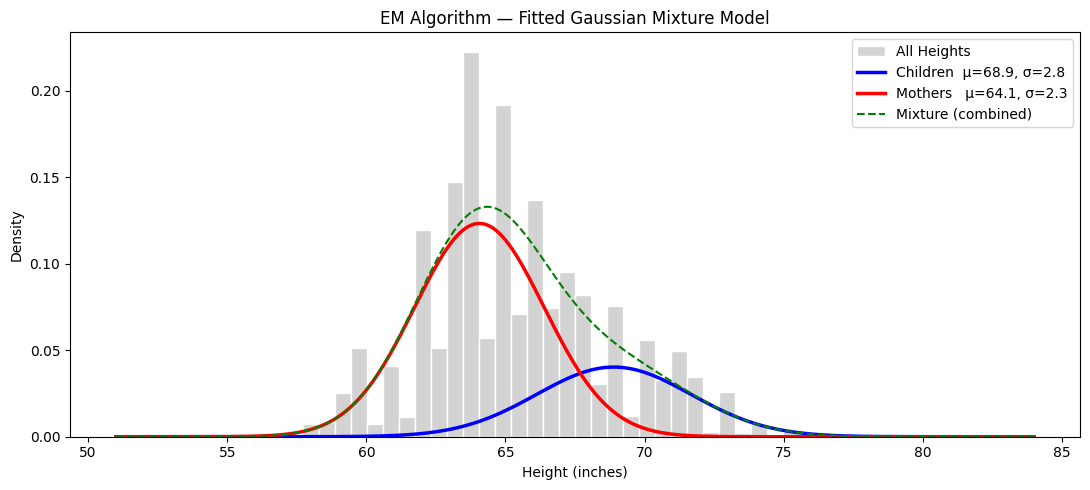

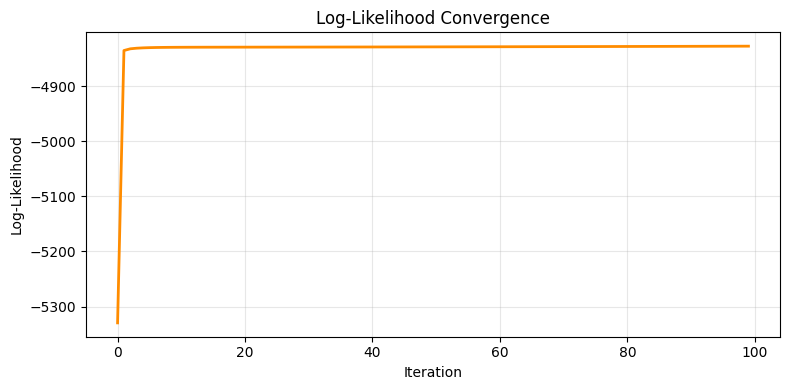

In [32]:
# Plot 1: Fitted Gaussians over the data
x_range = np.linspace(all_heights.min() - 5, all_heights.max() + 5, 300)

plt.figure(figsize=(11, 5))
plt.hist(all_heights, bins=40, density=True, color='lightgray', edgecolor='white', label='All Heights')
plt.plot(x_range, pi1 * gaussian_pdf(x_range, mu1, sigma1), 'b-', linewidth=2.5, label=f'Children  μ={mu1:.1f}, σ={sigma1:.1f}')
plt.plot(x_range, pi2 * gaussian_pdf(x_range, mu2, sigma2), 'r-', linewidth=2.5, label=f'Mothers   μ={mu2:.1f}, σ={sigma2:.1f}')
plt.plot(x_range, pi1 * gaussian_pdf(x_range, mu1, sigma1) + pi2 * gaussian_pdf(x_range, mu2, sigma2),
         'g--', linewidth=1.5, label='Mixture (combined)')
plt.title('EM Algorithm — Fitted Gaussian Mixture Model')
plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Log-Likelihood over iterations
plt.figure(figsize=(8, 4))
plt.plot(log_likelihoods, color='darkorange', linewidth=2)
plt.title('Log-Likelihood Convergence')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()